<a href="https://colab.research.google.com/github/srirammulukuntla11/AIEC/blob/main/Banknote_Perceptron_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Download the Banknote Authentication dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

df = pd.read_csv(
    url,
    header=None,
    names=["Variance", "Skewness", "Curtosis", "Entropy", "Class"]
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1372, 5)


,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
print("Dataset Information")
print("--------------------")

print("Number of samples:", len(df))
print("Number of features:", len(df.columns) - 1)

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nDataset statistics:")
display(df.describe())

Dataset Information
--------------------
Number of samples: 1372
Number of features: 4

Class distribution:
Class
0    762
1    610
Name: count, dtype: int64

Dataset statistics:


,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [5]:
# Input features
X = df[["Variance", "Skewness", "Curtosis", "Entropy"]].values

# Target/output
y = df["Class"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1372, 4)
y shape: (1372,)


In [6]:
# Normalize the input features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original first sample:")
print(X[0])

print("\nNormalized first sample:")
print(X_scaled[0])

Original first sample:
[ 3.6216   8.6661  -2.8073  -0.44699]

Normalized first sample:
[ 1.12180565  1.14945512 -0.97597007  0.35456135]


In [7]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1097
Testing samples: 275


In [9]:
class SimplePerceptron:

    def __init__(self, learning_rate=0.01, max_epochs=1000):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs

        self.weights = None
        self.bias = 0

        self.epochs = 0
        self.converged = False
        self.errors_per_epoch = []

    # Step activation function
    def step_function(self, z):
        return 1 if z >= 0 else 0

    # Prediction for one sample
    def predict_single(self, x):
        weighted_sum = np.dot(x, self.weights) + self.bias
        prediction = self.step_function(weighted_sum)

        return prediction, weighted_sum

    # Train perceptron
    def fit(self, X, y):

        # Initialize weights to zero
        self.weights = np.zeros(X.shape[1])

        # Initialize bias
        self.bias = 0

        self.errors_per_epoch = []

        for epoch in range(self.max_epochs):

            errors = 0

            for x, actual in zip(X, y):

                # Calculate weighted sum
                weighted_sum = np.dot(x, self.weights) + self.bias

                # Apply step activation
                prediction = self.step_function(weighted_sum)

                # Calculate error
                error = actual - prediction

                # Update weights
                self.weights = (
                    self.weights +
                    self.learning_rate * error * x
                )

                # Update bias
                self.bias = (
                    self.bias +
                    self.learning_rate * error
                )

                if error != 0:
                    errors += 1

            self.errors_per_epoch.append(errors)

            # Current epoch number
            self.epochs = epoch + 1

            # If there are no errors, training has converged
            if errors == 0:
                self.converged = True
                break

        return self

    # Predict multiple samples
    def predict(self, X):

        predictions = []

        for x in X:
            prediction, _ = self.predict_single(x)
            predictions.append(prediction)

        return np.array(predictions)

    # Calculate weighted sums
    def decision_function(self, X):

        return np.dot(X, self.weights) + self.bias

In [10]:
# Create and train the perceptron

perceptron = SimplePerceptron(
    learning_rate=0.01,
    max_epochs=1000
)

perceptron.fit(X_train, y_train)

print("Training completed!")
print("Converged:", perceptron.converged)
print("Epochs:", perceptron.epochs)
print("Final weights:", perceptron.weights)
print("Final bias:", perceptron.bias)

Training completed!
Converged: False
Epochs: 1000
Final weights: [-0.27224238 -0.33894143 -0.31031577 -0.01138547]
Final bias: -0.13999999999999999


In [11]:
# Predict the test data

y_pred = perceptron.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy * 100, "%")

Test Accuracy: 98.18181818181819 %


In [12]:
# Calculate weighted sums

weighted_sums = perceptron.decision_function(X_test)

results = pd.DataFrame({
    "Actual Class": y_test,
    "Predicted Class": y_pred,
    "Weighted Sum": weighted_sums
})

print("Banknote Classification Results")
print("--------------------------------")

display(results.head(20))

print("\nClassification Accuracy:",
      round(accuracy * 100, 2), "%")

Banknote Classification Results
--------------------------------


,Actual Class,Predicted Class,Weighted Sum
0,0,0,-0.544877
1,1,1,0.164424
2,0,0,-0.057049
3,1,1,0.148989
4,1,1,0.243264
5,1,1,0.117418
6,0,0,-0.511330
7,0,0,-0.567719
8,0,0,-0.469916
9,1,1,0.036314



Classification Accuracy: 98.18 %


In [13]:
def decision_boundary_explorer(feature1, feature2):

    feature_names = ["Variance", "Skewness", "Curtosis", "Entropy"]

    print("\n======================================")
    print("DECISION BOUNDARY EXPLORER")
    print("======================================")

    print("Selected features:")
    print("1.", feature_names[feature1])
    print("2.", feature_names[feature2])

    # Select two features
    X_pair = X[:, [feature1, feature2]]

    # Normalize
    scaler_pair = StandardScaler()
    X_pair_scaled = scaler_pair.fit_transform(X_pair)

    # Split
    X_train_pair, X_test_pair, y_train_pair, y_test_pair = train_test_split(
        X_pair_scaled,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # Train
    model = SimplePerceptron(
        learning_rate=0.01,
        max_epochs=1000
    )

    model.fit(X_train_pair, y_train_pair)

    # Predict
    predictions = model.predict(X_test_pair)

    accuracy = accuracy_score(y_test_pair, predictions)

    print("\nFinal weights:", model.weights)
    print("Final bias:", model.bias)
    print("Epochs:", model.epochs)
    print("Converged:", model.converged)
    print("Accuracy:", round(accuracy * 100, 2), "%")

    print("\nDecision Boundary:")
    print(
        f"{model.weights[0]:.4f} * {feature_names[feature1]} + "
        f"{model.weights[1]:.4f} * {feature_names[feature2]} + "
        f"{model.bias:.4f} = 0"
    )

    # Plot
    plt.figure(figsize=(8, 6))

    for class_value in [0, 1]:

        mask = y_test_pair == class_value

        plt.scatter(
            X_test_pair[mask, 0],
            X_test_pair[mask, 1],
            label=f"Class {class_value}"
        )

    # Decision boundary
    x_values = np.linspace(
        X_pair_scaled[:, 0].min(),
        X_pair_scaled[:, 0].max(),
        100
    )

    if abs(model.weights[1]) > 1e-10:

        y_values = (
            -(model.weights[0] * x_values + model.bias)
            / model.weights[1]
        )

        plt.plot(
            x_values,
            y_values,
            label="Decision Boundary"
        )

    plt.xlabel(feature_names[feature1])
    plt.ylabel(feature_names[feature2])
    plt.title("Perceptron Decision Boundary")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model


DECISION BOUNDARY EXPLORER
Selected features:
1. Variance
2. Skewness

Final weights: [-0.02891976 -0.02786783]
Final bias: 3.469446951953614e-18
Epochs: 1000
Converged: False
Accuracy: 86.18 %

Decision Boundary:
-0.0289 * Variance + -0.0279 * Skewness + 0.0000 = 0


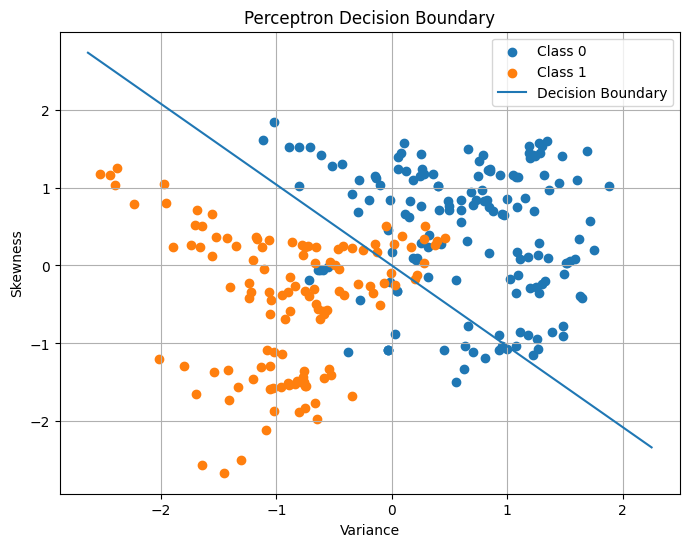

In [14]:
model_pair = decision_boundary_explorer(0, 1)


DECISION BOUNDARY EXPLORER
Selected features:
1. Variance
2. Curtosis

Final weights: [-0.02571765  0.00097984]
Final bias: -0.009999999999999997
Epochs: 1000
Converged: False
Accuracy: 86.18 %

Decision Boundary:
-0.0257 * Variance + 0.0010 * Curtosis + -0.0100 = 0


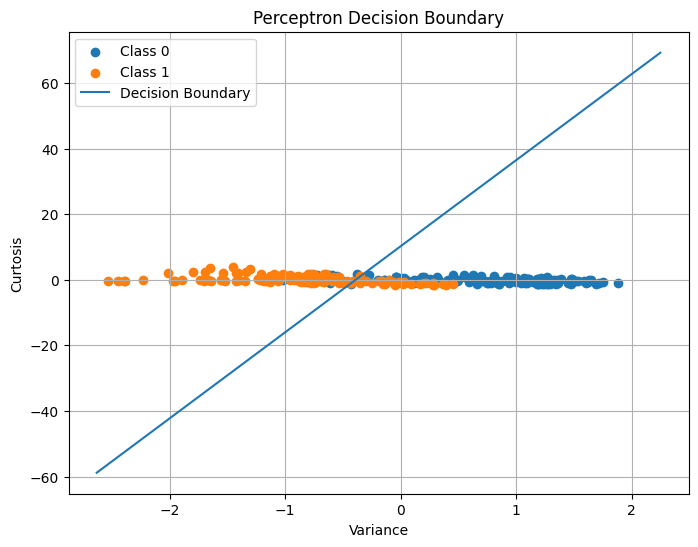

In [15]:
decision_boundary_explorer(0, 2)

In [17]:
from itertools import combinations

def feature_pair_challenge():

    feature_names = [
        "Variance",
        "Skewness",
        "Curtosis",
        "Entropy"
    ]

    results = []

    for f1, f2 in combinations(range(4), 2):

        X_pair = X[:, [f1, f2]]

        scaler_pair = StandardScaler()
        X_pair_scaled = scaler_pair.fit_transform(X_pair)

        X_train_pair, X_test_pair, y_train_pair, y_test_pair = train_test_split(
            X_pair_scaled,
            y,
            test_size=0.20,
            random_state=42,
            stratify=y
        )

        model = SimplePerceptron(
            learning_rate=0.01,
            max_epochs=1000
        )

        model.fit(X_train_pair, y_train_pair)

        predictions = model.predict(X_test_pair)

        accuracy = accuracy_score(
            y_test_pair,
            predictions
        )

        errors = np.sum(
            y_test_pair != predictions
        )

        results.append({
            "Feature Pair":
                f"{feature_names[f1]} + {feature_names[f2]}",

            "Epochs":
                model.epochs,

            "Accuracy (%)":
                round(accuracy * 100, 2),

            "Misclassified":
                int(errors),

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="Accuracy (%)",
        ascending=False
    )

    print("\n======================================")
    print("FEATURE PAIR SEPARABILITY CHALLENGE")
    print("======================================")

    display(results_df)

    return results_df

In [18]:
pair_results = feature_pair_challenge()


FEATURE PAIR SEPARABILITY CHALLENGE


,Feature Pair,Epochs,Accuracy (%),Misclassified,Converged
0,Variance + Skewness,1000,86.18,38,False
1,Variance + Curtosis,1000,86.18,38,False
2,Variance + Entropy,1000,79.27,57,False
4,Skewness + Entropy,1000,74.18,71,False
3,Skewness + Curtosis,1000,62.55,103,False
5,Curtosis + Entropy,1000,49.09,140,False


In [19]:
def sample_order_challenge():

    orders = {}

    # Original
    orders["Original"] = np.arange(len(X_train))

    # Reverse
    orders["Reverse"] = np.arange(len(X_train))[::-1]

    # Random
    rng = np.random.default_rng(42)

    orders["Random"] = rng.permutation(len(X_train))

    # Class-wise grouped
    class_0_indices = np.where(y_train == 0)[0]
    class_1_indices = np.where(y_train == 1)[0]

    orders["Class-wise"] = np.concatenate([
        class_0_indices,
        class_1_indices
    ])

    results = []

    for order_name, indices in orders.items():

        X_ordered = X_train[indices]
        y_ordered = y_train[indices]

        model = SimplePerceptron(
            learning_rate=0.01,
            max_epochs=1000
        )

        model.fit(X_ordered, y_ordered)

        predictions = model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        results.append({
            "Sample Order": order_name,
            "Epochs": model.epochs,
            "Weights": np.round(model.weights, 4),
            "Bias": round(model.bias, 4),
            "Accuracy (%)": round(accuracy * 100, 2),
            "Converged": model.converged
        })

    results_df = pd.DataFrame(results)

    print("\n======================================")
    print("TRAINING SAMPLE ORDER CHALLENGE")
    print("======================================")

    display(results_df)

    return results_df

In [20]:
order_results = sample_order_challenge()


TRAINING SAMPLE ORDER CHALLENGE


,Sample Order,Epochs,Weights,Bias,Accuracy (%),Converged
0,Original,1000,"[-0.2722, -0.3389, -0.3103, -0.0114]",-0.14,98.18,False
1,Reverse,1000,"[-0.2657, -0.3089, -0.2891, -0.0081]",-0.10,97.82,False
2,Random,1000,"[-0.2794, -0.3192, -0.2765, -0.0083]",-0.13,98.55,False
3,Class-wise,1000,"[-0.2771, -0.3316, -0.2587, -0.0283]",-0.10,98.18,False


In [21]:
def borderline_sample_detector(top_n=5):

    # Weighted sums for test samples
    weighted_sums = perceptron.decision_function(X_test)

    # Distance from boundary = absolute weighted sum
    distances = np.abs(weighted_sums)

    predictions = perceptron.predict(X_test)

    borderline_df = pd.DataFrame({
        "Sample Index": np.arange(len(X_test)),
        "Weighted Sum": weighted_sums,
        "Distance from Boundary": distances,
        "Predicted Class": predictions
    })

    # Add original feature values
    feature_df = pd.DataFrame(
        X_test,
        columns=[
            "Variance",
            "Skewness",
            "Curtosis",
            "Entropy"
        ]
    )

    borderline_df = pd.concat(
        [
            borderline_df,
            feature_df.reset_index(drop=True)
        ],
        axis=1
    )

    # Sort by distance
    borderline_df = borderline_df.sort_values(
        by="Distance from Boundary"
    )

    print("\n======================================")
    print("BORDERLINE SAMPLE DETECTOR")
    print("======================================")

    display(borderline_df.head(top_n))

    return borderline_df.head(top_n)

In [22]:
borderline_samples = borderline_sample_detector()


BORDERLINE SAMPLE DETECTOR


,Sample Index,Weighted Sum,Distance from Boundary,Predicted Class,Variance,Skewness,Curtosis,Entropy
266,266,-0.000864,0.000864,0,-1.453284,-2.659025,3.755838,-0.679179
223,223,0.008734,0.008734,1,-0.036772,-1.087038,0.736730,0.096587
114,114,0.008738,0.008738,1,-0.036786,-1.087038,0.736730,0.096587
221,221,0.008738,0.008738,1,-0.036786,-1.087038,0.736730,0.096587
153,153,0.019298,0.019298,1,-0.760677,-1.493692,1.752778,0.891436


In [23]:
def test_logic_gate(name, X_gate, y_gate, max_epochs=20):

    model = SimplePerceptron(
        learning_rate=0.1,
        max_epochs=max_epochs
    )

    model.fit(X_gate, y_gate)

    predictions = model.predict(X_gate)

    accuracy = accuracy_score(
        y_gate,
        predictions
    )

    print("\n-----------------------------")
    print(name)
    print("-----------------------------")

    print("Final weights:", model.weights)
    print("Final bias:", model.bias)
    print("Epochs:", model.epochs)
    print("Accuracy:", accuracy * 100, "%")
    print("Converged:", model.converged)

    result = pd.DataFrame({
        "Input 1": X_gate[:, 0],
        "Input 2": X_gate[:, 1],
        "Actual": y_gate,
        "Predicted": predictions
    })

    display(result)

    return model

In [24]:
# Truth tables

X_logic = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

AND = np.array([0, 0, 0, 1])

OR = np.array([0, 1, 1, 1])

NAND = np.array([1, 1, 1, 0])

XOR = np.array([0, 1, 1, 0])

In [25]:
and_model = test_logic_gate("AND", X_logic, AND)

or_model = test_logic_gate("OR", X_logic, OR)

nand_model = test_logic_gate("NAND", X_logic, NAND)

xor_model = test_logic_gate("XOR", X_logic, XOR)


-----------------------------
AND
-----------------------------
Final weights: [0.2 0.1]
Final bias: -0.20000000000000004
Epochs: 4
Accuracy: 100.0 %
Converged: True


,Input 1,Input 2,Actual,Predicted
0,0,0,0,0
1,0,1,0,0
2,1,0,0,0
3,1,1,1,1



-----------------------------
OR
-----------------------------
Final weights: [0.1 0.1]
Final bias: -0.1
Epochs: 4
Accuracy: 100.0 %
Converged: True


,Input 1,Input 2,Actual,Predicted
0,0,0,0,0
1,0,1,1,1
2,1,0,1,1
3,1,1,1,1



-----------------------------
NAND
-----------------------------
Final weights: [-0.2 -0.1]
Final bias: 0.2
Epochs: 6
Accuracy: 100.0 %
Converged: True


,Input 1,Input 2,Actual,Predicted
0,0,0,1,1
1,0,1,1,1
2,1,0,1,1
3,1,1,0,0



-----------------------------
XOR
-----------------------------
Final weights: [-0.1  0. ]
Final bias: 0.0
Epochs: 20
Accuracy: 50.0 %
Converged: False


,Input 1,Input 2,Actual,Predicted
0,0,0,0,1
1,0,1,1,1
2,1,0,1,0
3,1,1,0,0


In [26]:
def feature_removal_challenge():

    feature_names = [
        "Variance",
        "Skewness",
        "Curtosis",
        "Entropy"
    ]

    # Baseline model
    baseline_model = SimplePerceptron(
        learning_rate=0.01,
        max_epochs=1000
    )

    baseline_model.fit(X_train, y_train)

    baseline_predictions = baseline_model.predict(X_test)

    baseline_accuracy = accuracy_score(
        y_test,
        baseline_predictions
    )

    results = []

    for remove_index in range(4):

        keep_indices = [
            i for i in range(4)
            if i != remove_index
        ]

        X_reduced = X[:, keep_indices]

        scaler_reduced = StandardScaler()

        X_reduced_scaled = scaler_reduced.fit_transform(
            X_reduced
        )

        X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
            X_reduced_scaled,
            y,
            test_size=0.20,
            random_state=42,
            stratify=y
        )

        model = SimplePerceptron(
            learning_rate=0.01,
            max_epochs=1000
        )

        model.fit(X_train_r, y_train_r)

        predictions = model.predict(X_test_r)

        accuracy = accuracy_score(
            y_test_r,
            predictions
        )

        drop = (
            baseline_accuracy - accuracy
        ) * 100

        results.append({
            "Removed Feature":
                feature_names[remove_index],

            "Accuracy (%)":
                round(accuracy * 100, 2),

            "Accuracy Drop (%)":
                round(drop, 2),

            "Epochs":
                model.epochs,

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(results)

    print("\n======================================")
    print("FEATURE REMOVAL CHALLENGE")
    print("======================================")

    print(
        "Baseline Accuracy:",
        round(baseline_accuracy * 100, 2),
        "%"
    )

    display(results_df)

    return results_df

In [27]:
removal_results = feature_removal_challenge()


FEATURE REMOVAL CHALLENGE
Baseline Accuracy: 98.18 %


,Removed Feature,Accuracy (%),Accuracy Drop (%),Epochs,Converged
0,Variance,78.91,19.27,1000,False
1,Skewness,80.00,18.18,1000,False
2,Curtosis,84.36,13.82,1000,False
3,Entropy,98.55,-0.36,1000,False


In [28]:
print("\n======================================")
print("PERCEPTRON CLASSIFICATION REPORT")
print("======================================")

print("\nAccuracy:")
print(round(accuracy * 100, 2), "%")

print("\nEpochs:")
print(perceptron.epochs)

print("\nConverged:")
print(perceptron.converged)

print("\nFinal Weights:")
for name, weight in zip(
    ["Variance", "Skewness", "Curtosis", "Entropy"],
    perceptron.weights
):
    print(f"{name}: {weight:.6f}")

print("\nFinal Bias:")
print(perceptron.bias)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Forged", "Genuine"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


PERCEPTRON CLASSIFICATION REPORT

Accuracy:
98.18 %

Epochs:
1000

Converged:
False

Final Weights:
Variance: -0.272242
Skewness: -0.338941
Curtosis: -0.310316
Entropy: -0.011385

Final Bias:
-0.13999999999999999

Classification Report:
              precision    recall  f1-score   support

      Forged       0.99      0.97      0.98       153
     Genuine       0.97      0.99      0.98       122

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275


Confusion Matrix:
[[149   4]
 [  1 121]]


In [29]:
def show_menu():

    while True:

        print("\n")
        print("=" * 60)
        print(" BANKNOTE PERCEPTRON DECISION BOUNDARY CHALLENGE")
        print("=" * 60)

        print("1. Banknote Classification using Perceptron")
        print("2. Decision Boundary Explorer")
        print("3. Feature Pair Separability Challenge")
        print("4. Training Sample Order Challenge")
        print("5. Borderline Sample Detector")
        print("6. XOR Limitation Demonstrator")
        print("7. Perceptron Feature Removal Challenge")
        print("8. Perceptron Classification Report")
        print("9. Exit")

        print("=" * 60)

        choice = input("Enter your choice: ")

        # ----------------------------------
        # OPTION 1
        # ----------------------------------

        if choice == "1":

            print("\nBANKNOTE CLASSIFICATION")

            model = SimplePerceptron(
                learning_rate=0.01,
                max_epochs=1000
            )

            model.fit(X_train, y_train)

            predictions = model.predict(X_test)

            weighted_sums = model.decision_function(X_test)

            accuracy_value = accuracy_score(
                y_test,
                predictions
            )

            results = pd.DataFrame({
                "Actual Class": y_test,
                "Predicted Class": predictions,
                "Weighted Sum": weighted_sums
            })

            display(results.head(20))

            print(
                "\nAccuracy:",
                round(accuracy_value * 100, 2),
                "%"
            )

            print("Epochs:", model.epochs)
            print("Converged:", model.converged)

        # ----------------------------------
        # OPTION 2
        # ----------------------------------

        elif choice == "2":

            print("\nFeature numbers:")

            print("0 → Variance")
            print("1 → Skewness")
            print("2 → Curtosis")
            print("3 → Entropy")

            f1 = int(input("Enter first feature number: "))
            f2 = int(input("Enter second feature number: "))

            decision_boundary_explorer(f1, f2)

        # ----------------------------------
        # OPTION 3
        # ----------------------------------

        elif choice == "3":

            feature_pair_challenge()

        # ----------------------------------
        # OPTION 4
        # ----------------------------------

        elif choice == "4":

            sample_order_challenge()

        # ----------------------------------
        # OPTION 5
        # ----------------------------------

        elif choice == "5":

            borderline_sample_detector()

        # ----------------------------------
        # OPTION 6
        # ----------------------------------

        elif choice == "6":

            print("\nXOR LIMITATION DEMONSTRATOR")

            test_logic_gate(
                "AND",
                X_logic,
                AND
            )

            test_logic_gate(
                "OR",
                X_logic,
                OR
            )

            test_logic_gate(
                "NAND",
                X_logic,
                NAND
            )

            test_logic_gate(
                "XOR",
                X_logic,
                XOR
            )

        # ----------------------------------
        # OPTION 7
        # ----------------------------------

        elif choice == "7":

            feature_removal_challenge()

        # ----------------------------------
        # OPTION 8
        # ----------------------------------

        elif choice == "8":

            model = SimplePerceptron(
                learning_rate=0.01,
                max_epochs=1000
            )

            model.fit(X_train, y_train)

            predictions = model.predict(X_test)

            accuracy_value = accuracy_score(
                y_test,
                predictions
            )

            print("\n======================================")
            print("PERCEPTRON CLASSIFICATION REPORT")
            print("======================================")

            print(
                "Accuracy:",
                round(accuracy_value * 100, 2),
                "%"
            )

            print("Epochs:", model.epochs)
            print("Converged:", model.converged)

            print("\nWeights:")

            for name, weight in zip(
                ["Variance", "Skewness", "Curtosis", "Entropy"],
                model.weights
            ):
                print(
                    f"{name}: {weight:.6f}"
                )

            print("\nBias:")
            print(model.bias)

            print("\nClassification Report:")

            print(
                classification_report(
                    y_test,
                    predictions,
                    target_names=[
                        "Forged",
                        "Genuine"
                    ]
                )
            )

            print("Confusion Matrix:")

            print(
                confusion_matrix(
                    y_test,
                    predictions
                )
            )

        # ----------------------------------
        # OPTION 9
        # ----------------------------------

        elif choice == "9":

            print("\nThank you!")
            print("Exiting program...")

            break

        else:

            print(
                "\nInvalid choice. "
                "Please enter a number from 1 to 9."
            )

In [31]:
show_menu()



 BANKNOTE PERCEPTRON DECISION BOUNDARY CHALLENGE
1. Banknote Classification using Perceptron
2. Decision Boundary Explorer
3. Feature Pair Separability Challenge
4. Training Sample Order Challenge
5. Borderline Sample Detector
6. XOR Limitation Demonstrator
7. Perceptron Feature Removal Challenge
8. Perceptron Classification Report
9. Exit
Enter your choice: 9

Thank you!
Exiting program...
